# Notebook 3: Data Preprocessing
**CRISP-DM Phase 3 — Data Preparation**

Feature engineering, sklearn pipeline (impute → encode → scale), and train/val/test splitting.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

%load_ext autoreload
%autoreload 2

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from data_cleaner import DataCleaner
from feature_enginner import FeatureEngineer
from data_preprocesor import DataPreprocessor

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Load & Clean

In [2]:
df_raw   = pd.read_csv('../data/processed/all_waves_clean.csv')
cleaner  = DataCleaner()
df_clean = cleaner.fit_transform(df_raw)
print(f'After cleaning: {df_clean.shape}')

After cleaning: (20278, 38)


## 3. Feature Engineering
Domain-informed derived features:
- **Household composition**: adults_ratio, is_large_hh, dependency_ratio
- **Housing quality**: roof_quality, floor_quality, improved_water, improved_sanitation, housing_quality_idx
- **Asset wealth**: modern_asset_score (phone×1 + TV×2 + fridge×3)
- **Labour**: labour_intensity, is_fully_dependent
- **Vulnerability**: shock_breadth, is_multi_shock
- **Geography**: is_urban, is_addis, is_peripheral
- **Head human capital**: head_prime_working_age, head_elderly, educated_prime_head

In [3]:
fe = FeatureEngineer()
df = fe.engineer_all(df_clean)

print(f'Before FE: {df_clean.shape[1]} columns')
print(f'After FE:  {df.shape[1]} columns')
print(f'New features ({len(fe.created_features_)}):')
pd.Series(fe.created_features_, name='engineered_feature').to_frame()

Before FE: 38 columns
After FE:  57 columns
New features (19):


,engineered_feature
0,adults_ratio
1,is_large_hh
2,is_single_person
3,roof_quality
4,floor_quality
5,improved_water
6,improved_sanitation
7,clean_fuel
8,housing_quality_idx
9,modern_asset_score


## 4. Feature Statistics (Post-Engineering)

In [4]:
feat_cols = [
    'hh_size','adulteq','head_age','rooms','housing_score','housing_quality_idx',
    'modern_asset_score','hh_n_workers','dependency_ratio','adults_ratio','n_shocks'
]
feat_cols = [c for c in feat_cols if c in df.columns]
df[feat_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
hh_size,20278.0000,4.5493,2.3487,1.0000,3.0000,4.0000,6.0000,19.0000
adulteq,20278.0000,3.7194,1.9346,0.7400,2.3000,3.5000,4.9200,14.4400
head_age,20278.0000,44.2829,15.2436,11.0000,32.0000,41.0000,54.0000,100.0000
rooms,20278.0000,5.4929,9.6080,0.0000,0.0000,1.0000,6.0000,63.0000
housing_score,20278.0000,0.3088,0.2431,0.0000,0.1167,0.2417,0.5459,0.8185
housing_quality_idx,20278.0000,0.6174,0.0914,0.1000,0.6000,0.6000,0.6200,1.0000
modern_asset_score,20278.0000,0.2379,0.7908,0.0000,0.0000,0.0000,0.0000,6.0000
hh_n_workers,20278.0000,0.5752,0.9135,0.0000,0.0000,0.0000,1.0000,4.0000
dependency_ratio,20278.0000,0.1757,0.0875,0.0000,0.1103,0.1800,0.2400,0.5238
adults_ratio,20278.0000,0.8243,0.0875,0.4762,0.7600,0.8200,0.8897,1.0000


## 5. Train / Validation / Test Split
Stratified split to preserve class distribution:
- **Train**: 65% (model fitting)
- **Validation**: 15% (hyperparameter tuning)
- **Test**: 20% (final evaluation, touched once)

In [5]:
dp = DataPreprocessor()
splits = dp.fit(df, test_size=0.20, val_size=0.15)

split_summary = pd.DataFrame([
    {'split':'Train',      'n': splits['split_sizes']['train']},
    {'split':'Validation', 'n': splits['split_sizes']['val']},
    {'split':'Test',       'n': splits['split_sizes']['test']},
])
split_summary['pct'] = (split_summary['n'] / split_summary['n'].sum() * 100).round(1)
split_summary

,split,n,pct
0,Train,13180,65.0000
1,Validation,3042,15.0000
2,Test,4056,20.0000


In [6]:
print(f"Feature matrix shape: {splits['X_train'].shape}")
print(f"Total features: {splits['n_features']}")
print(f"Classes: {splits['label_classes']}")

Feature matrix shape: (13180, 0)
Total features: 0
Classes: [1 2 3 4 5]


## 6. Class Balance Across Splits

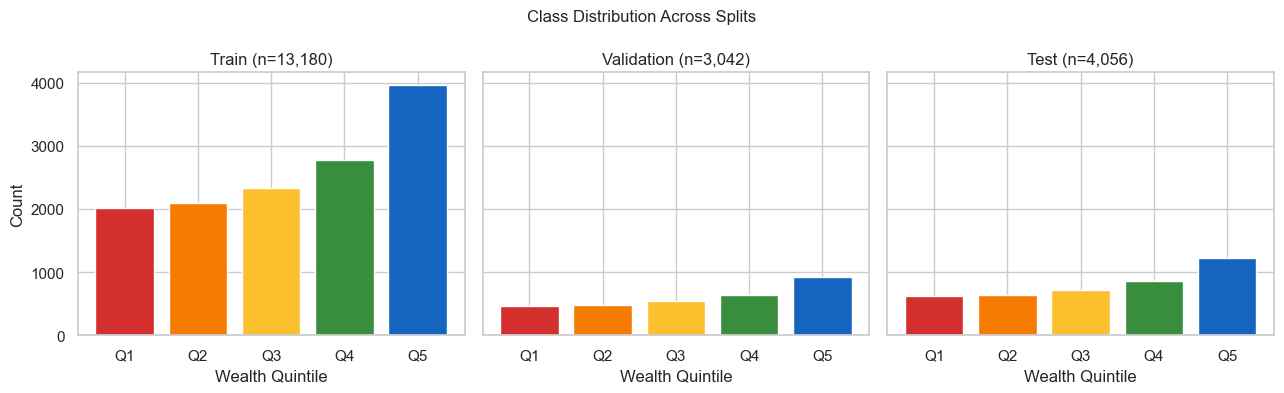

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']

for ax, key, title in zip(axes,
    ['y_train','y_val','y_test'],
    ['Train','Validation','Test']):
    vals, cnts = np.unique(splits[key], return_counts=True)
    ax.bar([f'Q{int(v)}' for v in vals], cnts, color=colors, edgecolor='white')
    ax.set_title(f'{title} (n={len(splits[key]):,})')
    ax.set_xlabel('Wealth Quintile')
    if ax == axes[0]:
        ax.set_ylabel('Count')

plt.suptitle('Class Distribution Across Splits', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/split_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Pipeline Summary

In [8]:
# Show transformer groups
groups = {
    'Continuous (StandardScaler)': dp.CONTINUOUS,
    'Binary (passthrough)':        dp.BINARY,
    'Ordinal housing (OrdinalEncoder)': dp.ORDINAL_HOUSING,
    'Ordinal settlement': dp.ORDINAL_SETTLEMENT,
    'Nominal (OneHotEncoder)':     dp.NOMINAL,
}
rows = []
for group, cols in groups.items():
    avail = [c for c in cols if c in df.columns]
    rows.append({'transformer': group, 'n_features': len(avail),
                 'features': ', '.join(avail)})
pd.DataFrame(rows)

,transformer,n_features,features
0,Continuous (StandardScaler),12,"hh_size, adulteq, head_age, head_age_sq, hh_n_..."
1,Binary (passthrough),12,"head_sex, is_female_headed, head_literate, hh_..."
2,Ordinal housing (OrdinalEncoder),6,"roof, wall, floor, water, toilet, fuel"
3,Ordinal settlement,1,settlement
4,Nominal (OneHotEncoder),2,"region, wave"


## 8. Save Pipeline

In [9]:
dp.save('../models/preprocessor.pkl')
print('Preprocessor saved.')

Preprocessor saved.
